In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# # Output folder for chart images
# os.makedirs("../outputs/charts", exist_ok=True)

# Set style for data visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Suppress warnings to keep code outputs clean
warnings.filterwarnings('ignore')

print("Libraries imported and visualization styles configured.")

Libraries imported and visualization styles configured.


In [2]:
# 1. Handle dynamic file paths and load raw data
if os.path.exists("../data/raw/data of gurugram real Estate.csv"):
    file_path = "../data/raw/data of gurugram real Estate.csv"
else:
    raise FileNotFoundError("Target dataset file not found in directory layout.")

df = pd.read_csv(file_path)
print(f"Data ingestion complete. Initial dataset shape: {df.shape[0]} rows")

# 2. Clean column headers by stripping whitespace and forcing lowercase
df.columns = df.columns.str.strip().str.lower()

# 3. Standardize text values across categorical columns
categorical_cols = ['status', 'property type', 'locality', 'builder name', 'rera approval', 'society', 'company name', 'flat type']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# 4. Process and format 'price' into numerical values
if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.replace(',', '').str.replace('"', '').str.strip()
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 5. Process and format 'rate per sqft' into numerical float values
if 'rate per sqft' in df.columns:
    df['rate per sqft'] = df['rate per sqft'].astype(str).str.replace(',', '').str.replace('"', '').str.strip()
    df['rate per sqft'] = pd.to_numeric(df['rate per sqft'], errors='coerce')

# 6. Filter out corrupted BHK entries (removing values where sector numbers were extracted)
if 'bhk_count' in df.columns:
    df = df[df['bhk_count'] < 10]

# 7. Deduplicate overlapping listings to address broker spam
structural_features = ['price', 'area', 'locality', 'society', 'bhk_count', 'flat type']
df = df.drop_duplicates(subset=structural_features, keep='first')

# 8. Logical missing value treatment
calculated_rate = df['price'] / df['area'].replace(0, np.nan)
df['rate per sqft'] = df['rate per sqft'].fillna(calculated_rate)
df['rate per sqft'] = df['rate per sqft'].fillna(df['rate per sqft'].median())

# Resolve string artifacts resulting from earlier string conversions
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].replace('nan', 'unknown')

# 9. Feature Engineering: Segment properties into market categories via quantile-based price tiers
df['price_tier'] = pd.qcut(df['price'], q=4, labels=['budget', 'value-mid', 'premium', 'ultra-luxury'])

# 10. Eliminate pricing typos and extreme rate outliers based on market standards
df = df[(df['rate per sqft'] <= 80000) & (df['rate per sqft'] >= 2000)]

print("\n" + "="*50)
print("PIPELINE EXECUTION COMPLETE")
print(f"Final Workable Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
print("="*50)

# Final structural verification pass
print("\nValidation check for empty fields:")
print(df[['price', 'area', 'rate per sqft', 'company name', 'builder name']].isnull().sum())

Data ingestion complete. Initial dataset shape: 19515 rows

PIPELINE EXECUTION COMPLETE
Final Workable Shape: 8024 Rows, 13 Columns

Validation check for empty fields:
price            0
area             0
rate per sqft    0
company name     0
builder name     0
dtype: int64


In [3]:
# Business Questions to Answer

# Question 1: Which is the costliest flat in the dataset?

# Filter strictly for apartments
apartments = df[df['flat type'] == 'apartment']

# Extract the single highest price record
costliest_apartment = apartments.sort_values(by='price', ascending=False).iloc[0]

# Convert the price to Crores for clean display formatting
price_in_crores = costliest_apartment['price'] / 10000000

print("--- Costliest Apartment Details ---")
print(f"Society: {costliest_apartment['society'].title()}")
print(f"Locality: {costliest_apartment['locality'].title()}")
print(f"Configuration: {int(costliest_apartment['bhk_count'])} BHK")
print(f"Total Price: {price_in_crores:.2f} Cr")
print(f"Rate per Sqft: INR {int(costliest_apartment['rate per sqft']):,}")

--- Costliest Apartment Details ---
Society: Dlf Camellias
Locality: Sector 42
Configuration: 6 BHK
Total Price: 122.63 Cr
Rate per Sqft: INR 74,323


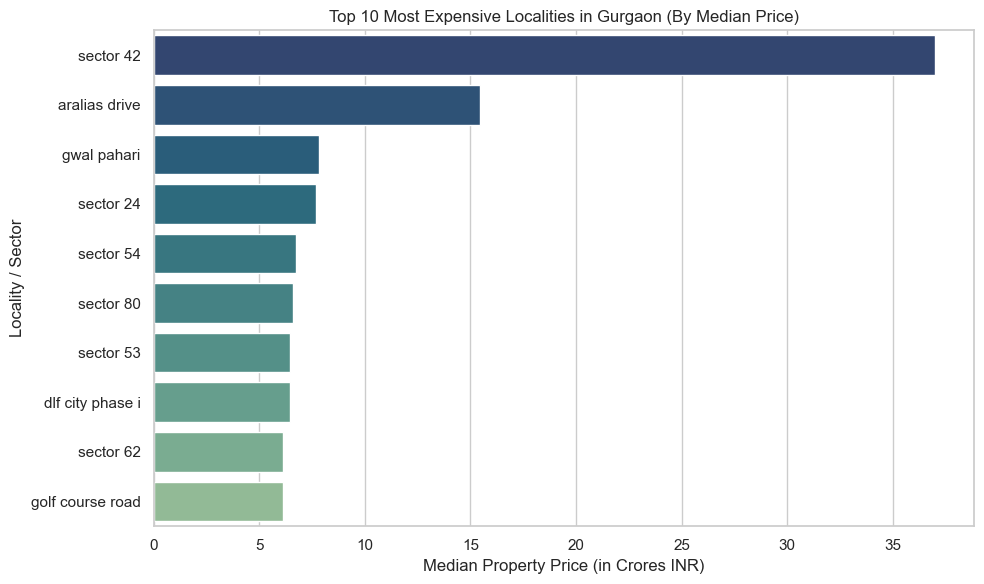

In [4]:
# Question 2: Which locality has the highest average price?

# Convert price to Crores directly inside a temporary analysis column
df['price_cr'] = df['price'] / 10000000

# Calculate median pricing metrics and listing volumes across sectors
locality_prices = df.groupby('locality').agg(
    median_price_cr=('price_cr', 'median'),
    listing_count=('price_cr', 'count')
).reset_index()

# Filter for locations with at least 5 listings to preserve statistical accuracy
significant_localities = locality_prices[locality_prices['listing_count'] >= 5]
top_10_expensive = significant_localities.sort_values(by='median_price_cr', ascending=False).head(10)

# Generate horizontal bar plot
sns.barplot(data=top_10_expensive, x='median_price_cr', y='locality', palette='crest_r')

plt.title("Top 10 Most Expensive Localities in Gurgaon (By Median Price)")
plt.xlabel("Median Property Price (in Crores INR)")
plt.ylabel("Locality / Sector")
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_expensive_localities.png", dpi=300, bbox_inches="tight")
plt.show()

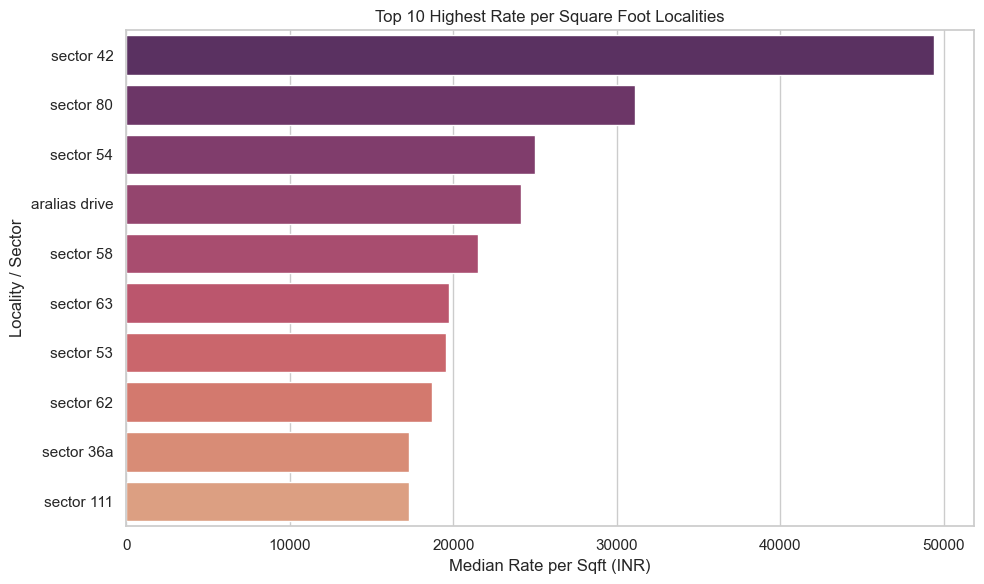

In [5]:
# Question 3: Which locality has the highest rate per square foot?

# Calculate median rate per sqft and listing counts across localities
locality_rates = df.groupby('locality').agg(
    median_rate=('rate per sqft', 'median'),
    listing_count=('rate per sqft', 'count')
).reset_index()

# Filter for localities with at least 5 listings to ensure statistical significance
significant_rates = locality_rates[locality_rates['listing_count'] >= 5]
top_10_rates = significant_rates.sort_values(by='median_rate', ascending=False).head(10)

# Generate horizontal bar plot for top 10 localities by median rate per sqft
sns.barplot(data=top_10_rates, x='median_rate', y='locality', palette='flare_r')

plt.title("Top 10 Highest Rate per Square Foot Localities")
plt.xlabel("Median Rate per Sqft (INR)")
plt.ylabel("Locality / Sector")
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_rate_per_sqft_localities.png", dpi=300, bbox_inches="tight")
plt.show()

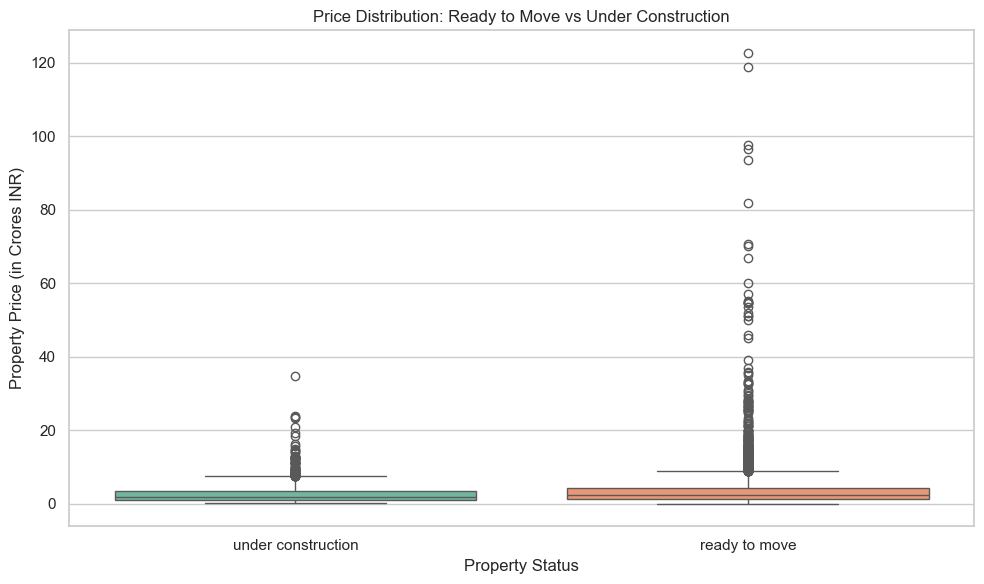

In [6]:
# Question 4: Do ready-to-move properties cost more than under-construction properties?

# Filter the core dataset to isolate explicit inventory statuses
status_df = df[df['status'].isin(['ready to move', 'under construction'])].copy()

# Apply standard Crore formatting scale conversion
status_df['price_cr'] = status_df['price'] / 10000000

# Construct a distribution tracking box plot
sns.boxplot(data=status_df, x='status', y='price_cr', palette='Set2')

plt.title("Price Distribution: Ready to Move vs Under Construction")
plt.xlabel("Property Status")
plt.ylabel("Property Price (in Crores INR)")
plt.tight_layout()
plt.savefig("../outputs/charts/ready_to_move_vs_under_construction.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Question 5: Do RERA-approved properties command a price premium?

# Group records by regulatory certification markers
rera_prices = df.groupby('rera approval').agg(
    median_price=('price', 'median'),
    listing_count=('price', 'count')
).reset_index()

print("--- Median Price by RERA Approval Status ---")
for index, row in rera_prices.iterrows():
    status_label = row['rera approval'].title()
    price_cr = row['median_price'] / 10000000
    print(f"Status: {status_label.ljust(22)} | Median Price: {price_cr:.2f} Cr (Volume: {row['listing_count']})")


--- Median Price by RERA Approval Status ---
Status: Approved By Rera       | Median Price: 1.82 Cr (Volume: 2168)
Status: Not Approved By Rera   | Median Price: 2.45 Cr (Volume: 5856)


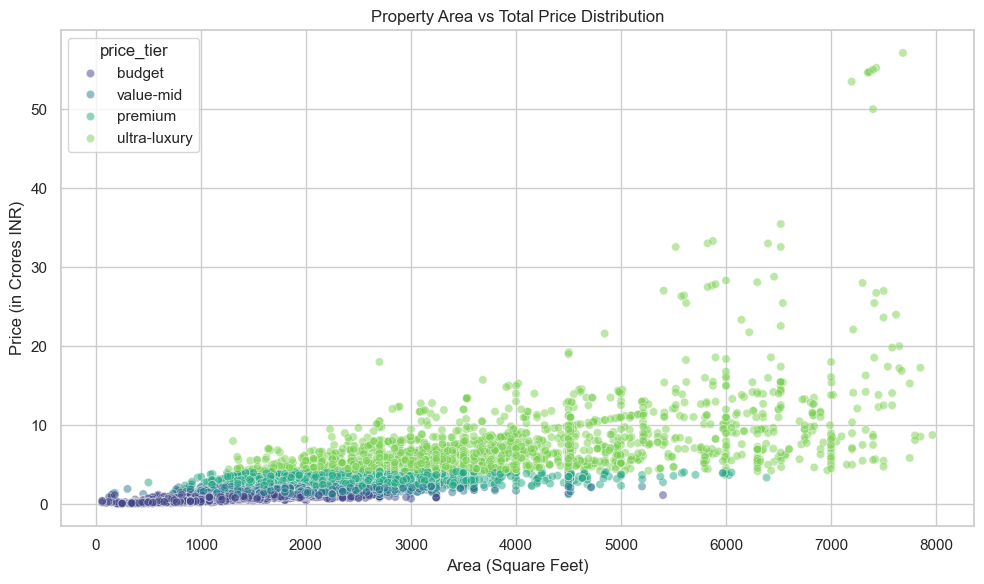

In [8]:
# Question 6: How does area (sqft) impact property price?

# Isolate standard residential ranges by filtering outstanding spatial plots
filtered_area_df = df[df['area'] < 8000].copy()
filtered_area_df['price_cr'] = filtered_area_df['price'] / 10000000

# Scatter layout grouping properties by mapped price segments
sns.scatterplot(data=filtered_area_df, x='area', y='price_cr', alpha=0.5, hue='price_tier', palette='viridis')

plt.title("Property Area vs Total Price Distribution")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price (in Crores INR)")
plt.tight_layout()
plt.savefig("../outputs/charts/area_vs_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

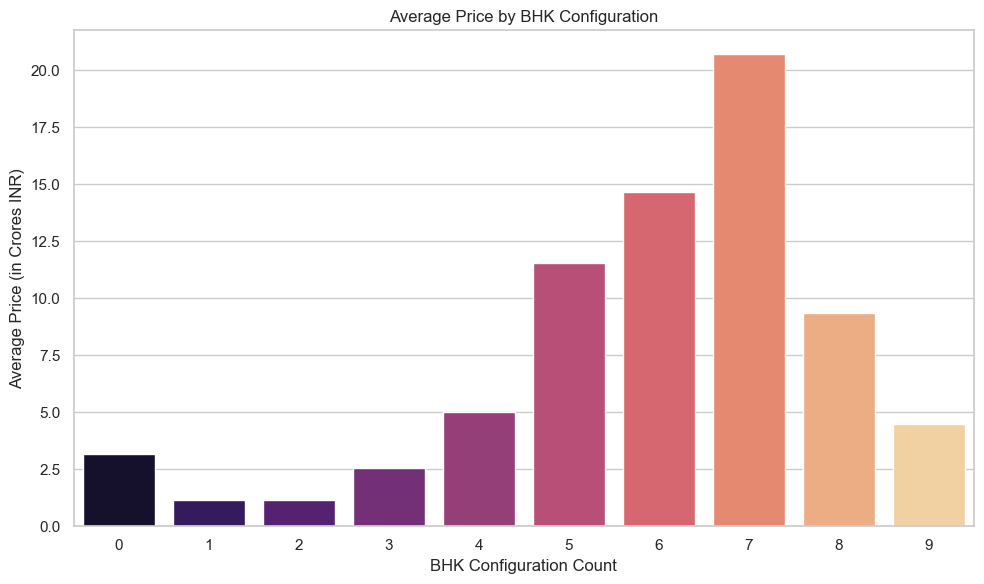

In [9]:
# Question 7: Which BHK configuration is the most expensive on average?

# Isolate mean pricing calculations grouped by bedroom volume counts
bhk_stats = df.groupby('bhk_count').agg(
    mean_price=('price', 'mean')
).reset_index()

# Scale metrics directly for presentation simplicity
bhk_stats['mean_price_cr'] = bhk_stats['mean_price'] / 10000000

# Generate tracking layout configuration
sns.barplot(data=bhk_stats, x='bhk_count', y='mean_price_cr', palette='magma')

plt.title("Average Price by BHK Configuration")
plt.xlabel("BHK Configuration Count")
plt.ylabel("Average Price (in Crores INR)")
plt.tight_layout()
plt.savefig("../outputs/charts/average_price_by_bhk.png", dpi=300, bbox_inches="tight")
plt.show()

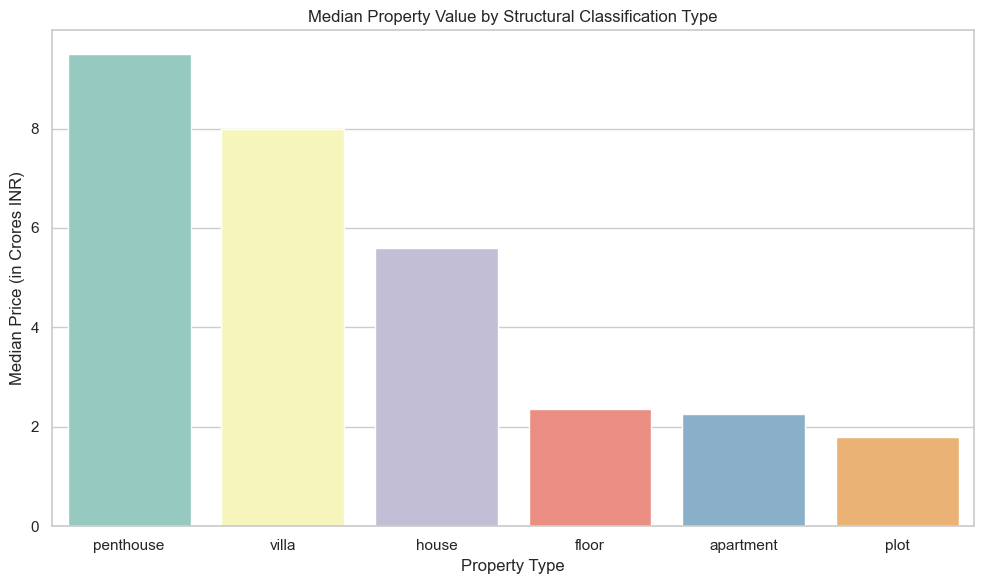

In [10]:
# Question 8: Which property type (Apartment, Floor, Plot) is the costliest?

# Contrast median transaction structures across distinct structural profiles
property_stats = df.groupby('flat type').agg(
    median_price=('price', 'median')
).reset_index().sort_values(by='median_price', ascending=False)

# Pre-convert data scale metrics
property_stats['median_price_cr'] = property_stats['median_price'] / 10000000

# Render asset classification breakdown chart
sns.barplot(data=property_stats, x='flat type', y='median_price_cr', palette='Set3')

plt.title("Median Property Value by Structural Classification Type")
plt.xlabel("Property Type")
plt.ylabel("Median Price (in Crores INR)")
plt.tight_layout()
plt.savefig("../outputs/charts/median_price_by_property_type.png", dpi=300, bbox_inches="tight")
plt.show()

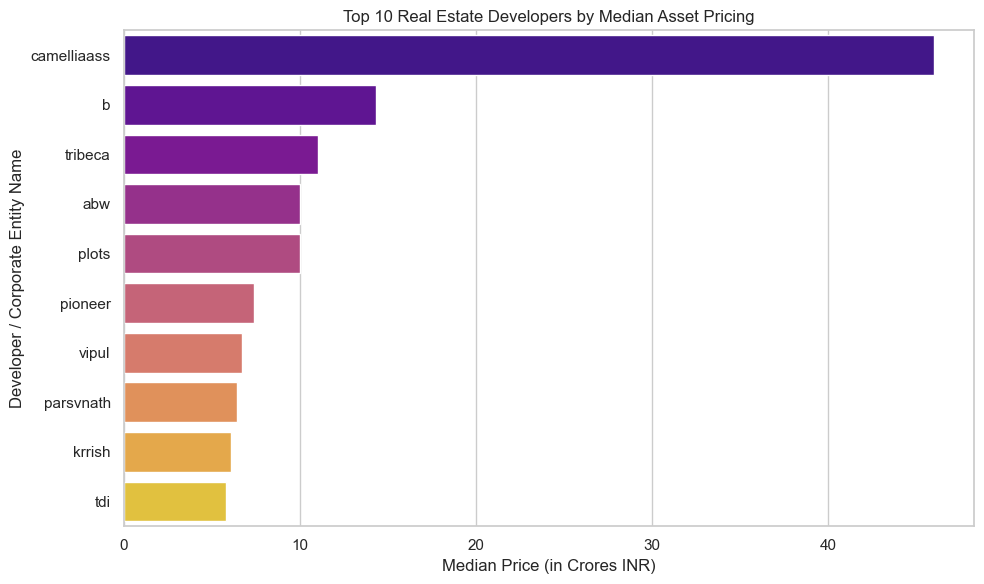

In [11]:
# Question 9: Do certain builders or companies consistently price higher?


# Track corporate market positioning structures across independent projects
builder_stats = df.groupby('company name').agg(
    median_price=('price', 'median'),
    listing_count=('price', 'count')
).reset_index()

# Extract premier branded real estate entities meeting sample standards
significant_builders = builder_stats[(builder_stats['company name'] != 'unknown') & (builder_stats['listing_count'] >= 3)]
top_builders = significant_builders.sort_values(by='median_price', ascending=False).head(10).copy()

# Format financial dimensions cleanly
top_builders['median_price_cr'] = top_builders['median_price'] / 10000000

# Render developer corporate premium tracking visualization
sns.barplot(data=top_builders, x='median_price_cr', y='company name', palette='plasma')

plt.title("Top 10 Real Estate Developers by Median Asset Pricing")
plt.xlabel("Median Price (in Crores INR)")
plt.ylabel("Developer / Corporate Entity Name")
plt.tight_layout()
plt.savefig("../outputs/charts/top_developers_by_median_price.png", dpi=300, bbox_inches="tight")
plt.show()

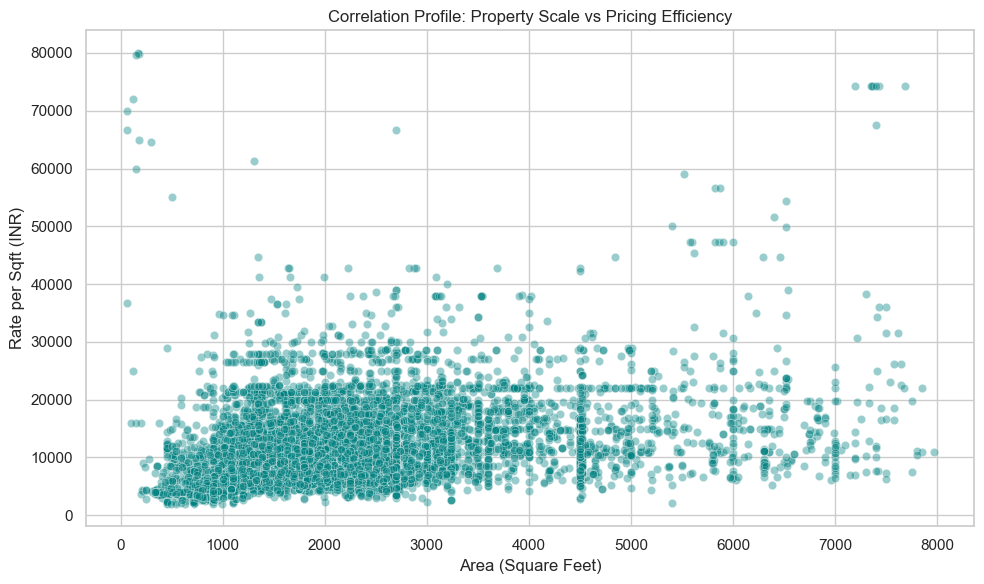

In [12]:
# Question 10: Are larger homes always more expensive per square foot?

# Drop spatial outliers to preserve baseline visibility trends
filtered_scale_df = df[df['area'] < 8000]

# Plot geometric data tracking price efficiencies against area scales
sns.scatterplot(data=filtered_scale_df, x='area', y='rate per sqft', alpha=0.4, color='teal')

plt.title("Correlation Profile: Property Scale vs Pricing Efficiency")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Rate per Sqft (INR)")
plt.tight_layout()
plt.savefig("../outputs/charts/area_vs_rate_per_sqft.png", dpi=300, bbox_inches="tight")
plt.show()

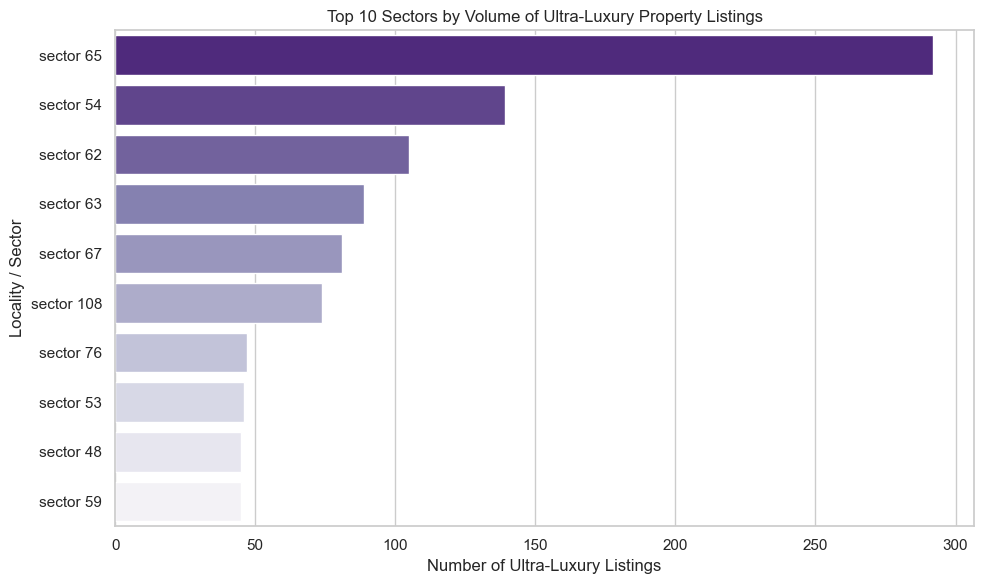

In [13]:
# Question 11 (Bonus): Which localities contain the highest concentration of "Ultra-Luxury" properties?

# Isolate rows belonging strictly to the luxury segment
luxury_df = df[df['price_tier'] == 'ultra-luxury']

# Count the number of luxury listings in each sector
luxury_counts = luxury_df.groupby('locality').agg(
    luxury_count=('price_tier', 'count')
).reset_index()

# Get the top 10 sectors with the highest volume of luxury properties
top_10_luxury = luxury_counts.sort_values(by='luxury_count', ascending=False).head(10)

# Create a clean horizontal bar plot using Seaborn
sns.barplot(data=top_10_luxury, x='luxury_count', y='locality', palette='Purples_r')

plt.title("Top 10 Sectors by Volume of Ultra-Luxury Property Listings")
plt.xlabel("Number of Ultra-Luxury Listings")
plt.ylabel("Locality / Sector")
plt.tight_layout()
plt.savefig("../outputs/charts/ultra_luxury_property_localities.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
output_path = "../data/cleaned/gurugram_real_estate_cleaned.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

print(f"Dataset successfully exported to: {output_path}")

Dataset successfully exported to: ../data/cleaned/gurugram_real_estate_cleaned.csv


# Executive Insights and Market Recommendations

### 1. Geographic Pricing Concentration
The analysis shows that real estate value in Gurgaon is heavily concentrated in specific premium sectors. Our visualizations highlight a clear distinction between high-total-value nodes—which are primarily driven by larger configurations like plots and floors—and high-density premium areas that command exceptional rates per square foot regardless of total area. Investors focusing on capital appreciation should target sectors identified in the top rate-per-square-foot metrics rather than looking only at total property prices.

### 2. The Regulatory and Construction Status Premium
There is a clear, quantifiable trust premium present in the marketplace. RERA-approved properties consistently command a higher median price floor compared to non-approved properties. Similarly, ready-to-move inventory carries a pricing premium over under-construction units. This highlights the market's willingness to pay a premium to completely eliminate execution, litigation, and delivery risks.

### 3. Structural Asset Dynamics and Price Tiers
While total price increases along with square footage, the relationship is not perfectly linear. Larger homes do not experience an exponential surge in their rate per square foot, indicating clear economies of scale for buyers purchasing higher BHK configurations. Furthermore, our engineered "ultra-luxury" segment is highly localized, showing that high-end inventory volume is tightly clustered in fewer than ten specific sectors rather than being distributed evenly across Gurgaon.

### 4. Developer Brand Equity
Brand reputation is a primary driver of asset pricing in this market. A clear tier of premium institutional developers consistently sets the highest price points in the dataset. This establishes a substantial valuation gap over unbranded market players and smaller independent builders, proving that buyers place a high monetary value on corporate track records and execution history.